# Monolayer Growth Comparison

Reproduce the monolayer colony-diameter comparison across BioDynaMo, Chaste, CompuTiX, PhysiCell, and TiSim, with experimental reference data. A second panel shows each tool's deviation from the experimental diameter.


## Step 1: Import Required Libraries

Use only the libraries needed for data loading, interpolation, path handling, and plotting.


In [9]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


## Step 2: Define Repository Paths and Output Folder

Keep each source path explicit so the inputs can be changed independently. The paths below follow the current repository locations.


In [10]:
ROOT = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents) if (parent / 'ResultAnalysis').is_dir()),
    Path.cwd(),
)

TISIM_CSV = ROOT / 'Tisim' / 'monolayer' / '2D disk.csv'
CHASTE_DAT = ROOT / 'Chaste' / 'monolayer' / 'results' / 'monolayer.dat'
PHYSICELL_CSV = ROOT / 'PhysiCell' / 'results' / 'monolayer_28' / 'monolayer_disk_summary.csv'
COMPUTIX_YAML = ROOT / 'CompuTiX' / 'monolayer' / 'results' / 'monolayer.yaml'

OUTPUT_DIR = ROOT / 'ResultAnalysis' / 'plots' / 'monolayer_plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)

INPUT_PATHS = {
    'TiSim': TISIM_CSV,
    'Chaste': CHASTE_DAT,
    'PhysiCell': PHYSICELL_CSV,
    'CompuTiX': COMPUTIX_YAML,
}

missing_paths = [path for path in INPUT_PATHS.values() if not path.is_file()]
if missing_paths:
    raise FileNotFoundError('Missing input file(s):\n' + '\n'.join(map(str, missing_paths)))

print(f'Repository root: {ROOT}')
print(f'Plot output directory: {OUTPUT_DIR}')


Repository root: /home/tntiniak/Work/observatory_benchmark
Plot output directory: /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/plots/monolayer_plots


## Step 3: Experimental and BioDynaMo Reference Series

BioDynaMo and the experimental reference have no on-disk result files for this benchmark, so their time (days) and diameter (μm) series are recorded directly here.


In [11]:
expe_dt_hours = [336, 386, 408, 481, 506, 646]
expe_dt = [hours / 24.0 for hours in expe_dt_hours]
expe_diam = [1140, 1400, 1590, 2040, 2250, 3040]

biodynamo_dt = [
    14, 14.8333333333333, 15.6666666666667, 16.5, 17.3333333333333, 18.1666666666666,
    18.9999999999999, 19.8333333333332, 20.6666666666665, 21.4999999999998, 22.333333333333,
    23.1666666666663, 23.9999999999996, 24.8333333333329, 25.6666666666665, 26.5,
]
biodynamo_diam = [
    1240, 1320, 1440, 1560, 1680, 1800, 1920, 2040, 2160, 2280, 2400, 2520, 2640, 2760, 2880, 3000,
]


## Step 4: Set Shared Plotting Style

Each simulator gets a consistent color, linestyle, linewidth, and transparency; the experimental reference is plotted as black markers.


In [12]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial', 'sans-serif'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'figure.dpi': 300,
})

results_order = ['BioDynaMo', 'Chaste', 'PhysiCell', 'TiSim', 'CompuTiX', 'Experimental']

COLORS = {
    'PhysiCell': '#4daf4a',
    'BioDynaMo': '#ff7f00',
    'Chaste': '#377eb8',
    'TiSim': '#984ea3',
    'CompuTiX': '#fd2a2a',
    'Experimental': '#000000',
}
LINESTYLES = {tool: '-' for tool in COLORS}
LINEWIDTHS = {tool: 1.8 for tool in COLORS}
LINEWIDTHS['Experimental'] = 2.5
ALPHAS = {tool: 0.7 for tool in COLORS}
ALPHAS['CompuTiX'] = 0.3
ALPHAS['Experimental'] = 0.8
MARKERS = {'Experimental': 'X'}


## Step 5: Load All Tool Outputs Into a Single Comparison Table

Each series is standardized to `dt` (time in days) and `diam` (colony diameter in μm). PhysiCell and CompuTiX are filtered to start from day 14, matching the experimental observation window.


In [13]:
df_exp = pd.DataFrame(data=zip(expe_dt, expe_diam), columns=['dt', 'diam'])
df_exp.insert(loc=2, column='Results', value='Experimental')

df_biod = pd.DataFrame(data=zip(biodynamo_dt, biodynamo_diam), columns=['dt', 'diam'])
df_biod.insert(loc=2, column='Results', value='BioDynaMo')

df_tisim_raw = pd.read_csv(TISIM_CSV, sep=',', engine='python')
df_tisim = pd.DataFrame({
    'dt': df_tisim_raw['time (day)'].iloc[140:],
    'diam': df_tisim_raw['diameter (um)'].iloc[140:],
    'Results': 'TiSim',
})

times, diameter, cells = [], [], []
with open(CHASTE_DAT) as results_file:
    for line in results_file:
        values = re.split('\t|,', line.replace('\n', ''))
        if len(values) == 1:
            continue
        times.append(float(values[0]))
        diameter.append(float(values[1]))
        cells.append(float(values[2]))
df_chaste = pd.DataFrame(data=zip(times, diameter), columns=['dt', 'diam'])
df_chaste['dt'] = df_chaste['dt'] / 24
df_chaste['Results'] = 'Chaste'
df_pc_raw = pd.read_csv(PHYSICELL_CSV, sep=',', engine='python')
# PhysiCell's clock starts at day 0; keep only the day 14-28 window to match experiment.
df_pc = pd.DataFrame({
    'dt': pd.to_numeric(df_pc_raw['timestep']) / 1440.0,
    'diam': pd.to_numeric(df_pc_raw['diameter']),
    'Results': 'PhysiCell',
})
df_pc = df_pc[(df_pc['dt'] >= 14) & (df_pc['dt'] <= 28)]

with open(COMPUTIX_YAML, 'r') as f:
    computix_results = yaml.safe_load(f)
t_results = np.array(computix_results['time']['values']) / 24.0  # To days
d_results = np.array(computix_results['d']['values'])
df_compu = pd.DataFrame(data=zip(t_results, d_results), columns=['dt', 'diam'])
df_compu = df_compu[df_compu['dt'] >= 14]
df_compu.insert(loc=2, column='Results', value='CompuTiX')

df_all = pd.concat(
    [df_exp, df_biod, df_tisim, df_pc, df_chaste, df_compu],
    ignore_index=True,
)
df_all = df_all.dropna(subset=['dt', 'diam']).sort_values('dt')
df_all


,dt,diam,Results
0,14.000000,1140.000000,Experimental
6,14.000000,1240.000000,BioDynaMo
142,14.000000,711.071288,PhysiCell
558,14.000000,1170.099785,CompuTiX
479,14.000000,1115.400000,Chaste
...,...,...,...
474,27.833333,1725.348770,PhysiCell
475,27.875000,1728.193034,PhysiCell
476,27.916667,1730.233174,PhysiCell
477,27.958333,1730.684111,PhysiCell


## Step 6: Plot Colony Diameter and Deviation From Experiment

The left panel shows colony diameter over time for every tool plus the experimental markers. The right panel shows each tool's deviation from a linear interpolation of the experimental diameter.


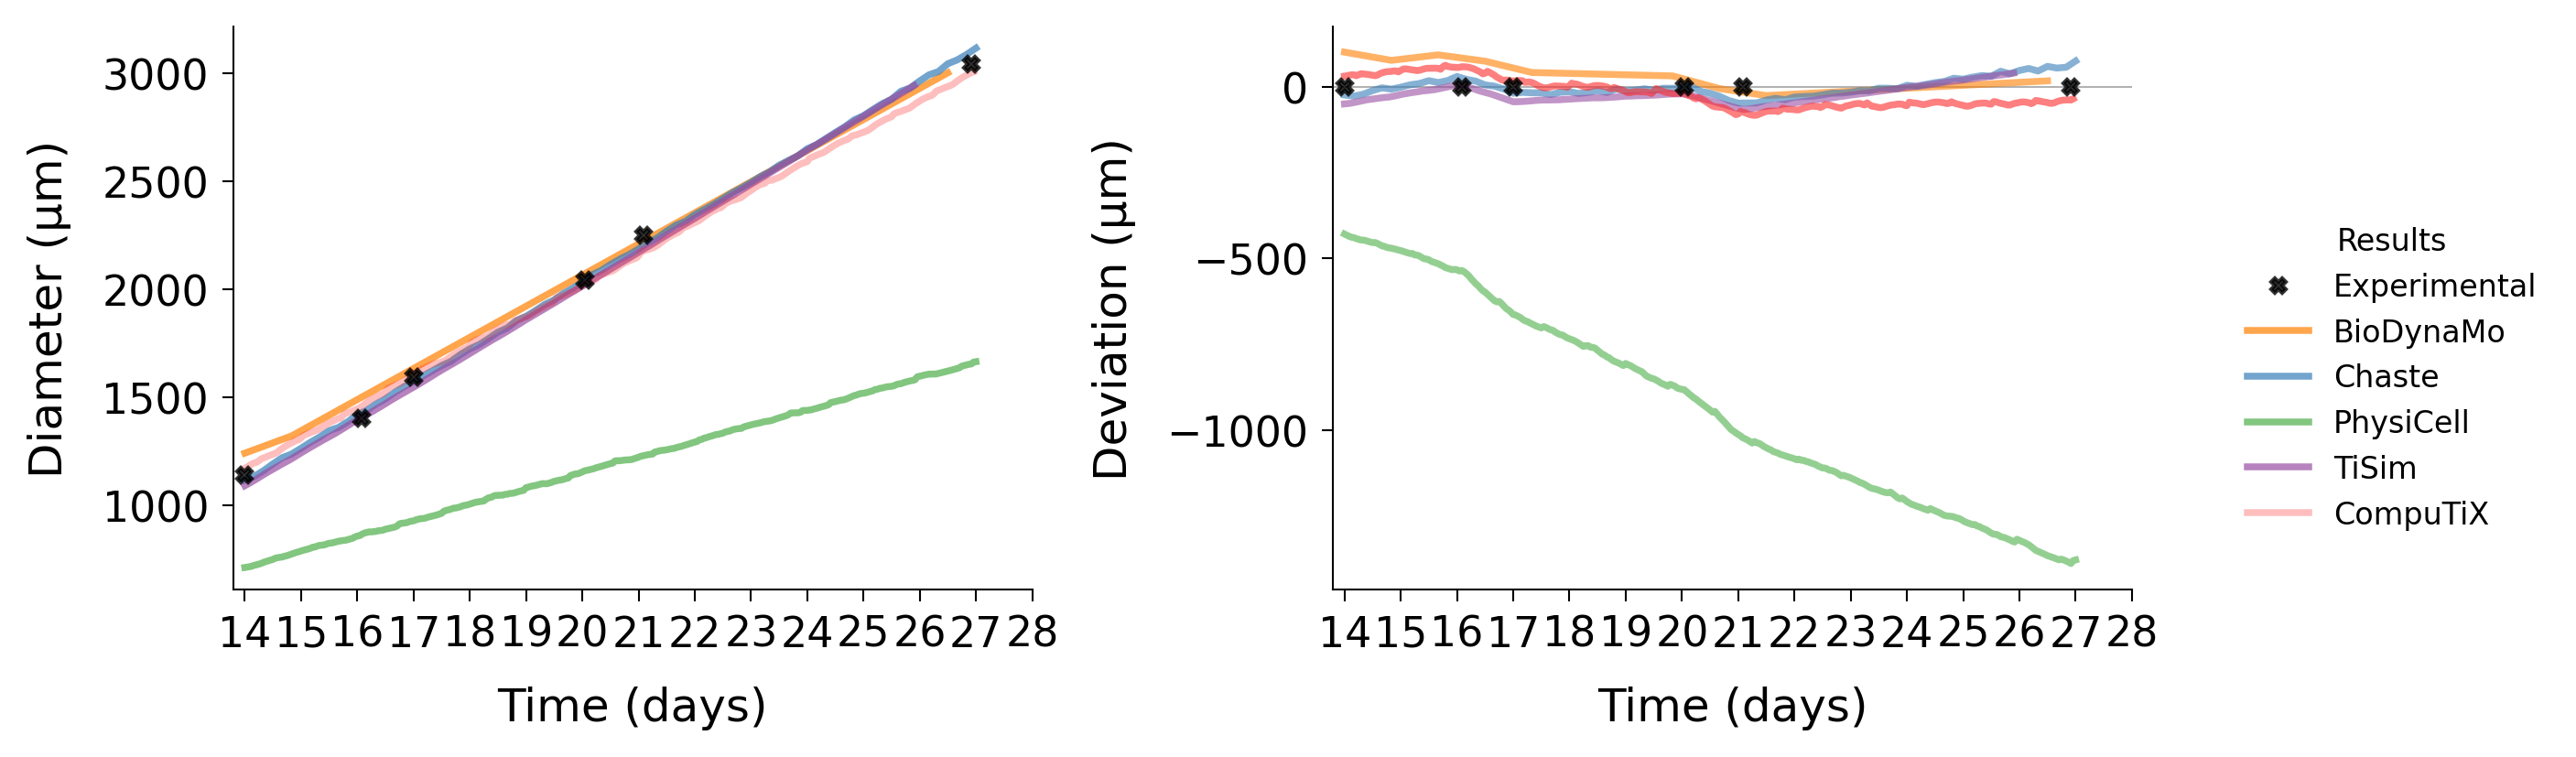

In [14]:
exp_interp = interp1d(
    df_exp['dt'].values, df_exp['diam'].values,
    kind='linear', bounds_error=False,
    fill_value=(df_exp['diam'].values[0], df_exp['diam'].values[-1]),
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2.8))

df_exp_plot = df_all[df_all['Results'] == 'Experimental']
ax1.plot(
    df_exp_plot['dt'], df_exp_plot['diam'],
    color=COLORS['Experimental'],
    label='Experimental',
    linestyle='None',
    marker=MARKERS.get('Experimental'),
    markersize=4,
    markeredgecolor='k',
    markerfacecolor=COLORS['Experimental'],
    alpha=ALPHAS['Experimental'],
    zorder=2,
)

for result in ['BioDynaMo', 'Chaste', 'PhysiCell', 'TiSim', 'CompuTiX']:
    df = df_all[(df_all['Results'] == result) & (df_all['dt'] <= 27)]
    ax1.plot(
        df['dt'], df['diam'],
        color=COLORS[result],
        label=result,
        linestyle=LINESTYLES[result],
        linewidth=LINEWIDTHS[result],
        alpha=ALPHAS[result],
        zorder=1,
    )

ax1.set_xlabel('Time (days)', labelpad=8, fontsize=12)
ax1.set_ylabel('Diameter (μm)', labelpad=8, fontsize=12)
ax1.set_xlim(13.8, 28)
ax1.set_xticks(np.arange(14, 29, 1))
ax1.set_ylim(bottom=df_all['diam'].min() - 100, top=df_all['diam'].max() + 100)
ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='both', which='major', labelsize=11)

for result in ['BioDynaMo', 'Chaste', 'PhysiCell', 'TiSim', 'CompuTiX']:
    df = df_all[(df_all['Results'] == result) & (df_all['dt'] <= 27)]
    deviations = df['diam'] - exp_interp(df['dt'])
    ax2.plot(
        df['dt'], deviations,
        color=COLORS[result],
        label=result,
        linestyle=LINESTYLES[result],
        linewidth=LINEWIDTHS[result],
        alpha=0.6,
        zorder=2,
    )

ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.5, zorder=1)
ax2.plot(
    df_exp_plot['dt'], np.zeros(len(df_exp_plot)),
    color=COLORS['Experimental'],
    label='Experimental',
    linestyle='None',
    marker=MARKERS.get('Experimental'),
    markersize=4,
    markeredgecolor='k',
    markerfacecolor=COLORS['Experimental'],
    alpha=ALPHAS['Experimental'],
    zorder=2,
)

ax2.set_xlabel('Time (days)', labelpad=8, fontsize=12)
ax2.set_ylabel('Deviation (μm)', labelpad=8, fontsize=12)
ax2.set_xlim(13.8, 28)
ax2.set_xticks(np.arange(14, 29, 1))
ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='both', which='major', labelsize=11)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels, title='Results',
    loc='center left', bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0., frameon=False,
)
fig.tight_layout()


## Step 7: Export the Figure to `ResultAnalysis/plots/monolayer_plots`

Save a high-resolution PNG and a vector SVG.


In [15]:
png_path = OUTPUT_DIR / 'monolayer_comparison_combined.png'
svg_path = OUTPUT_DIR / 'monolayer_comparison_combined.svg'

fig.savefig(png_path, dpi=300, bbox_inches='tight', pad_inches=0.1, format='png')
fig.savefig(svg_path, bbox_inches='tight', pad_inches=0.1, format='svg')

plt.show()

print(f'Saved PNG: {png_path}')
print(f'Saved SVG: {svg_path}')


Saved PNG: /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/plots/monolayer_plots/monolayer_comparison_combined.png
Saved SVG: /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/plots/monolayer_plots/monolayer_comparison_combined.svg
